In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv("15_jun_logs.csv", engine='python', on_bad_lines='skip')

In [4]:
print(df.head())

          id  bat_current bat_status  bat_volt  device_id json_value  \
0  249041350         1.35   Charging      13.6      12952        NaN   
1  249041351         0.00     Normal      14.4      11120        NaN   
2  249041355         0.00     Normal      13.2      11367        NaN   
3  249041358         0.00       Full      14.4      10459        NaN   
4  249041363         0.00     Normal      13.9      11345        NaN   

   load_current load_status  load_volt               metadata_date  \
0           0.0         OFF        0.0  2026-06-15 16:03:29.488000   
1           0.0         OFF        0.0  2026-06-15 16:03:29.635000   
2           0.0         OFF        0.0  2026-06-15 16:03:30.037000   
3           0.0         OFF        0.0  2026-06-15 16:03:30.377000   
4           0.0         OFF        0.0  2026-06-15 16:03:30.787000   

   pv_current  pv_volt  dod   ft  soc   wh  
0        1.15     15.2  NaN  NaN  NaN  NaN  
1        0.00     17.9  NaN  NaN  NaN  NaN  
2        0.

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6656 entries, 0 to 6655
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             6656 non-null   int64  
 1   bat_current    6656 non-null   float64
 2   bat_status     6656 non-null   object 
 3   bat_volt       6644 non-null   float64
 4   device_id      6656 non-null   int64  
 5   json_value     259 non-null    object 
 6   load_current   6656 non-null   float64
 7   load_status    6656 non-null   object 
 8   load_volt      6656 non-null   float64
 9   metadata_date  6656 non-null   object 
 10  pv_current     6656 non-null   float64
 11  pv_volt        6656 non-null   float64
 12  dod            289 non-null    float64
 13  ft             289 non-null    object 
 14  soc            277 non-null    float64
 15  wh             289 non-null    object 
dtypes: float64(8), int64(2), object(6)
memory usage: 832.1+ KB
None


In [6]:
print(df.isnull().sum())

id                  0
bat_current         0
bat_status          0
bat_volt           12
device_id           0
json_value       6397
load_current        0
load_status         0
load_volt           0
metadata_date       0
pv_current          0
pv_volt             0
dod              6367
ft               6367
soc              6379
wh               6367
dtype: int64


In [7]:
df = df.dropna(subset=['soc'])

print(df.shape)

(277, 16)


In [8]:
print(df.dtypes)

id                 int64
bat_current      float64
bat_status        object
bat_volt         float64
device_id          int64
json_value        object
load_current     float64
load_status       object
load_volt        float64
metadata_date     object
pv_current       float64
pv_volt          float64
dod              float64
ft                object
soc              float64
wh                object
dtype: object


In [9]:
#feature selection
features = [
    'bat_current',
    'bat_volt',
    'pv_current',
    'pv_volt',
    'load_current',
    'load_volt'
]

X = df[features]
y = df['soc']

print(X.head())
print(y.head())

     bat_current  bat_volt  pv_current  pv_volt  load_current  load_volt
34           0.0      14.4         0.0     21.1           0.0        0.0
59           0.0      15.3         0.0     20.6           0.0        0.0
107          0.0      14.2         0.0     20.9           0.0        0.0
112          0.0      15.3         0.0     19.9           0.0        0.0
135          0.0      14.4         0.0     19.7           0.0        0.0
34     100.0
59     100.0
107    100.0
112    100.0
135    100.0
Name: soc, dtype: float64


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 221
Testing samples: 56


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

In [13]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 9788.3750 - mae: 98.4257 - val_loss: 9914.4580 - val_mae: 99.5696
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 9758.1162 - mae: 98.2727 - val_loss: 9881.4043 - val_mae: 99.4025
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9722.6289 - mae: 98.0921 - val_loss: 9845.2588 - val_mae: 99.2194
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 9684.3955 - mae: 97.8995 - val_loss: 9802.3291 - val_mae: 99.0011
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9639.4336 - mae: 97.6709 - val_loss: 9752.4785 - val_mae: 98.7467
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 9585.9990 - mae: 97.3962 - val_loss: 9694.4111 - val_mae: 98.4494
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 9521.7412 - mae: 97.0614 - val_loss: 9627.8418 - val_mae: 98.1074
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 9451.2881 - mae: 96.6999 - val_loss: 9548.5762 - val_mae: 97.6976
Epoch 9/50
6/6 

In [15]:
loss, mae = model.evaluate(X_test, y_test)

print("Loss:", loss)
print("MAE:", mae)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 201.7107 - mae: 9.3578
Loss: 201.710693359375
MAE: 9.357815742492676


In [16]:
predictions = model.predict(X_test)

print(predictions[:5])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
[[ 95.95594]
 [ 96.98846]
 [ 84.83667]
 [ 60.97274]
 [107.44831]]


In [17]:
import pandas as pd

comparison = pd.DataFrame({
    'Actual SOC': y_test.values,
    'Predicted SOC': predictions.flatten()
})

print(comparison.head(10))

   Actual SOC  Predicted SOC
0       100.0      95.955940
1       100.0      96.988457
2       100.0      84.836670
3        21.0      60.972740
4       100.0     107.448311
5       100.0     106.027573
6       100.0      96.983391
7       100.0      95.030708
8       100.0      95.256630
9       100.0     106.027573


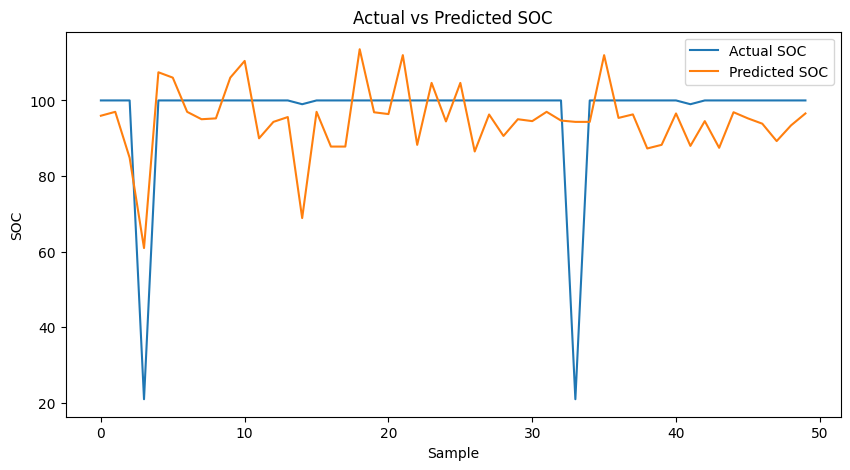

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test.values[:50], label='Actual SOC')
plt.plot(predictions[:50], label='Predicted SOC')

plt.xlabel("Sample")
plt.ylabel("SOC")

plt.title("Actual vs Predicted SOC")

plt.legend()

plt.show()

In [19]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

tflite_model = converter.convert()

INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpw62yugh6\assets


INFO:tensorflow:Assets written to: C:\Users\HP\AppData\Local\Temp\tmpw62yugh6\assets


Saved artifact at 'C:\Users\HP\AppData\Local\Temp\tmpw62yugh6'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 6), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2811754172240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811754172624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811754172432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811754173200: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811754173968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2811754174160: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [20]:
with open("solar_model.tflite", "wb") as f:
    f.write(tflite_model)

print("TFLite model saved successfully")

TFLite model saved successfully


In [21]:
import os

print(os.path.exists("solar_model.tflite"))

True


## TensorFlow Lite Conversion

The trained TensorFlow model was converted into TensorFlow Lite format (.tflite).

TensorFlow Lite models are lightweight and suitable for deployment on mobile devices and embedded systems.

This conversion enables the model to be used in real-time applications with lower memory and computational requirements.